In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Exploratory Data Analysis / Preprocessing</h1>

In [17]:
X_train=pd.read_csv('train.csv')
Y_train=pd.read_csv('train.csv', usecols=['Survived'])
X_test=pd.read_csv('test.csv')
Y_test=pd.read_csv('gender_submission.csv')
X=pd.read_csv('train.csv')

In [18]:
X_train=X_train.drop(columns=['PassengerId','Survived','Name','Ticket'])
X_test=X_test.drop(columns=['PassengerId'])


In [19]:
print(X_train.shape)
print(Y_train.shape)

(891, 8)
(891, 1)


In [20]:
X_train.isna().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [21]:
X_train['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [22]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,NaN,S
887,1,female,19.0,0,0,30.0000,B42,S
888,3,female,NaN,1,2,23.4500,NaN,S
889,1,male,26.0,0,0,30.0000,C148,C


In [23]:
def preprocessing(X_train):
    X_train['Has_Cabin']=~X_train['Cabin'].isna()
    X_train['Cabin_Class'] = X_train['Cabin'].str[0]
    X_train['Cabin_Class'] = X_train['Cabin_Class'].fillna('Unknown')
    X_train.drop('Cabin', axis=1, inplace=True)
    X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
    X_train=pd.get_dummies(X_train,columns=['Embarked','Sex','Cabin_Class'])
    return X_train

In [24]:
X_train=preprocessing(X_train)

In [25]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Cabin_Class_A,Cabin_Class_B,Cabin_Class_C,Cabin_Class_D,Cabin_Class_E,Cabin_Class_F,Cabin_Class_G,Cabin_Class_T,Cabin_Class_Unknown
0,3,22.0,1,0,7.2500,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
1,1,38.0,1,0,71.2833,True,True,False,False,True,False,False,False,True,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
3,1,35.0,1,0,53.1000,True,False,False,True,True,False,False,False,True,False,False,False,False,False,False
4,3,35.0,0,0,8.0500,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
887,1,19.0,0,0,30.0000,True,False,False,True,True,False,False,True,False,False,False,False,False,False,False
888,3,28.0,1,2,23.4500,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
889,1,26.0,0,0,30.0000,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False


In [26]:
Y_train

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [27]:
Y_train.nunique()

Survived    2
dtype: int64

<h2>Outlier Detection</h2>

In [28]:
X_train.describe()

,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

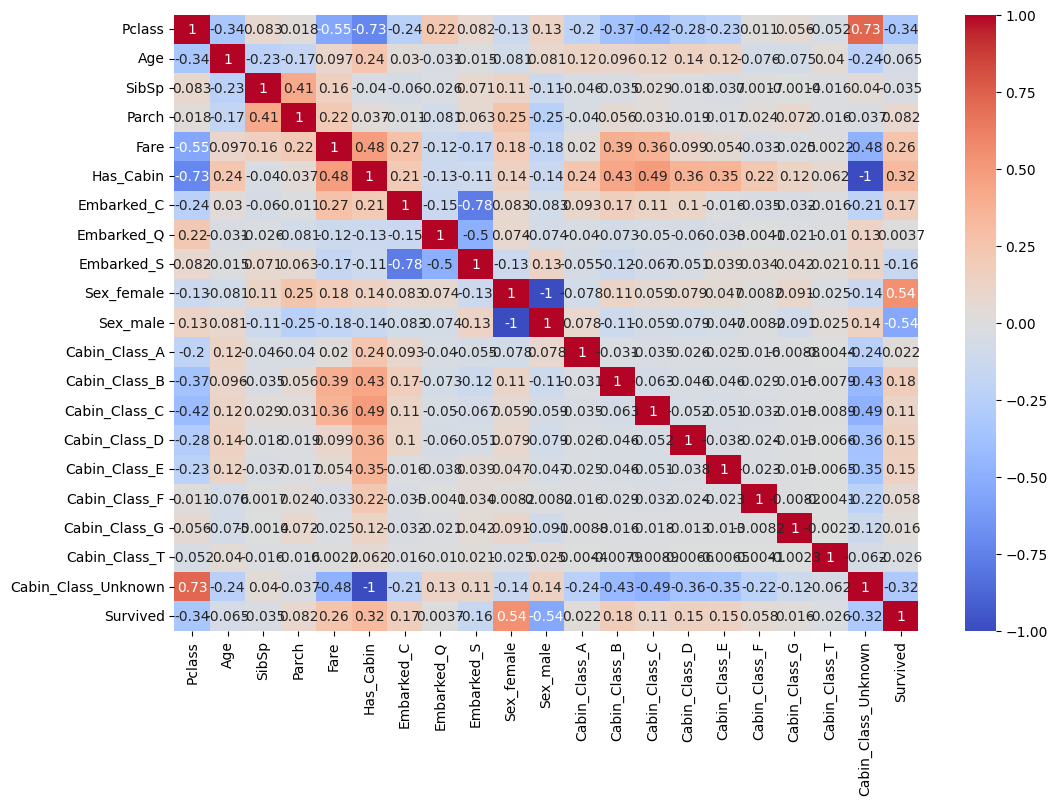

In [29]:
data=pd.concat([X_train,Y_train],axis=1)
corr=data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [30]:
Xmean=X_train.mean()
Xstd=X_train.std()
def norm(X):
    return ((X-Xmean)/Xstd)

In [31]:
X_train=norm(X_train)
X_test=norm(X_test)

In [32]:
X_train.isna().sum()

Pclass                 0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
Has_Cabin              0
Embarked_C             0
Embarked_Q             0
Embarked_S             0
Sex_female             0
Sex_male               0
Cabin_Class_A          0
Cabin_Class_B          0
Cabin_Class_C          0
Cabin_Class_D          0
Cabin_Class_E          0
Cabin_Class_F          0
Cabin_Class_G          0
Cabin_Class_T          0
Cabin_Class_Unknown    0
dtype: int64

In [33]:
X_train = X_train.to_numpy()
X_test=X_test.to_numpy()
Y_train = Y_train.to_numpy()
Y_test=Y_test.to_numpy()

<h1>Training</h1>

In [34]:
def z_calc(X,W,B):
    Z=np.matmul(X,W)+B
    Z = np.clip(Z, -500, 500)
    return Z

def g_calc(Z):
    return 1/(1+np.exp(-Z))

def compute_cost(Y_train,G_train,W_train,lambd=0):
    epsilon=1e-15
    G_train=np.clip(G_train, epsilon, 1 - epsilon)
    cost=-(Y_train*np.log(G_train)+(1-Y_train)*np.log(1-G_train))/G_train.shape[0]
    reg = (lambd / (2 * Y_train.size)) * np.sum(W_train**2)
    return cost.sum()+reg

In [35]:
W_train = np.ones((X_train.shape[1], 1))
B_train= 0.0

In [36]:
Z_train=z_calc(X_train,W_train,B_train)
G_train=g_calc(Z_train)
P_train=np.round(G_train)

In [37]:
print(X_train.shape)
print(Y_train.shape)
print(Z_train.shape)

(891, 20)
(891, 1)
(891, 1)


In [38]:
W_history=[]
B_history=[]
P_history=[]
J_history=[]
W_history.append(W_train)
B_history.append(B_train)
P_history.append(P_train)
J_history.append(compute_cost(Y_train,G_train,W_train))

In [39]:
def gradescent(epoch, alpha, W_history, J_history, B_history, P_history, X_train, Y_train, lambd=0):
    for i in range(epoch):
        W_current = W_history[-1]
        B_current = B_history[-1]

        Z_train = z_calc(X_train, W_current, B_current)
        G_train = g_calc(Z_train)

        # Gradient updates
        W_new = W_current - alpha* (X_train.T @ (G_train - Y_train) + lambd * W_current) / X_train.shape[0] 
        B_new = B_current - alpha / X_train.shape[0] * np.sum(G_train - Y_train)

        # Append new weights and biases
        W_history.append(W_new.copy())
        B_history.append(B_new)

        # Prediction and cost
        Z_train = z_calc(X_train, W_new, B_new)
        G_train = g_calc(Z_train)
        P_history.append(np.round(G_train))
        J_history.append(compute_cost(Y_train, G_train,W_history[-1]))

        if i % 10 == 0:
            print("Iteration:", i, "Cost:", J_history[-1])


In [40]:
epoch=3000
alpha=4.5
gradescent(epoch, alpha, W_history, J_history, B_history, P_history, X_train, Y_train)

Iteration: 0 Cost: 0.7045349893727528
Iteration: 10 Cost: 0.5446023183705555
Iteration: 20 Cost: 0.5412589722417549
Iteration: 30 Cost: 0.5409905867699796
Iteration: 40 Cost: 0.5408915422971095
Iteration: 50 Cost: 0.5408089712922324
Iteration: 60 Cost: 0.5407309504233816
Iteration: 70 Cost: 0.5406562849591909
Iteration: 80 Cost: 0.5405845943110111
Iteration: 90 Cost: 0.5405156356907562
Iteration: 100 Cost: 0.5404492426820013
Iteration: 110 Cost: 0.5403852953903718
Iteration: 120 Cost: 0.5403236998247383
Iteration: 130 Cost: 0.5402643756218188
Iteration: 140 Cost: 0.5402072493373888
Iteration: 150 Cost: 0.5401522509529215
Iteration: 160 Cost: 0.5400993121451445
Iteration: 170 Cost: 0.5400483655031698
Iteration: 180 Cost: 0.5399993442469525
Iteration: 190 Cost: 0.5399521822033544
Iteration: 200 Cost: 0.5399068139064191
Iteration: 210 Cost: 0.5398631747491379
Iteration: 220 Cost: 0.5398212011476899
Iteration: 230 Cost: 0.5397808306979975
Iteration: 240 Cost: 0.5397420023149924
Iteration: 

In [41]:
#best cost: Iteration: 990 Cost: 0.30232651808472094
#Iteration: 2990 Cost: 0.2964052591711286


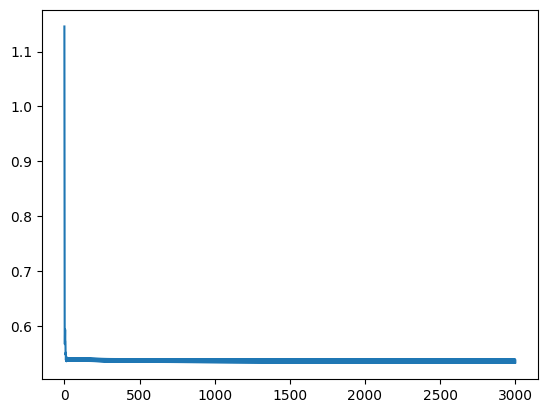

In [42]:
plt.plot(J_history)

In [43]:
W_train=W_history[-1]
B_train=B_history[-1]
Z_train=z_calc(X_train,W_train,B_train)
G_train=g_calc(Z_train)
P_train=np.round(G_train)

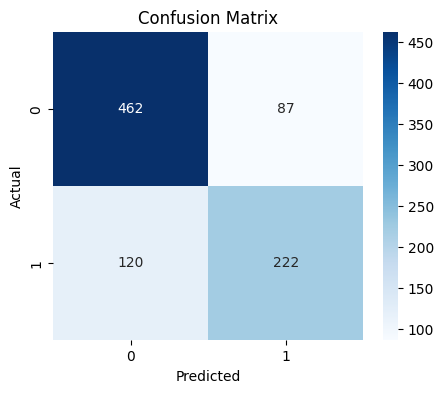

In [44]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, P_train)  
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [45]:
from sklearn.metrics import classification_report
print(classification_report(Y_train, P_train))


              precision    recall  f1-score   support

           0       0.79      0.84      0.82       549
           1       0.72      0.65      0.68       342

    accuracy                           0.77       891
   macro avg       0.76      0.75      0.75       891
weighted avg       0.76      0.77      0.77       891



In [46]:
count=0
for i in range(len(P_train)):
    if (P_train[i]==Y_train[i]):
        count+=1
print("Accuracy: ",count*100/len(P_train))

Accuracy:  76.76767676767676


In [908]:
# Accuracy 1 (Initial): 76.767676


<h1>Testing</h1>

In [50]:
X_test=preprocessing(X_test)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [47]:
y_pred=z_calc(X_test,W_train,B_train)
g_pred=g_calc(y_pred)
p_pred=np.round(g_pred)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 25)

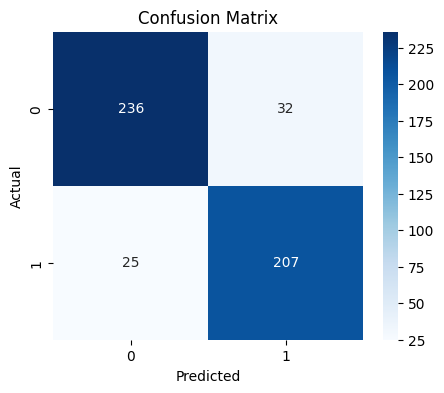

In [910]:
cm = confusion_matrix(Y_test, p_pred)  
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [911]:
print(classification_report(Y_test, p_pred))


              precision    recall  f1-score   support

       False       0.90      0.88      0.89       268
        True       0.87      0.89      0.88       232

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



In [912]:
count=0
for i in range(len(p_pred)):
    if (p_pred[i]==Y_test[i]):
        count+=1
print("Accuracy: ",count*100/len(p_pred))

Accuracy:  88.6
